# Select two paper examples of the surface PV-gradient method

Generate small AE and CE candidate pools for seamount-like and continental-slope encounters, inspect their maps, then select any two for a clean $1\times2$ paper figure. Candidate labels are screening aids; use the maps to confirm the geomorphology.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run inside seacofs_eddy_tilt_analysis or one of its subfolders')
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
import esp_pv_tools as ept

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
vertical = tilt.load_vert(paths, dic_form=False)
data = ept.load_cache()

## 1. Generate the candidate pools

Seamount-like candidates have strong local gradients but low vector coherence in deep water. Slope candidates have strong, coherently directed gradients at intermediate depth. Five different eddies are retained for each polarity and candidate type.

In [2]:
candidates = ept.select_gradient_example_candidates(
    data, n_per_group=25, strong_quantile=0.90,
    seamount_max_coherence=0.35, seamount_min_depth_m=3000,
    slope_min_coherence=0.70, slope_depth_range_m=(2500, 3500),
)

summary_columns = [
    'candidate_type', 'Cyc', 'rank', 'Eddy', 'Day', 'h',
    'PV_grad_mag', 'PV_grad_mean_local_mag', 'PV_grad_coherence',
    'PV_grad_topo_p90_local_mag',
]
# display(candidates[summary_columns].round(4))

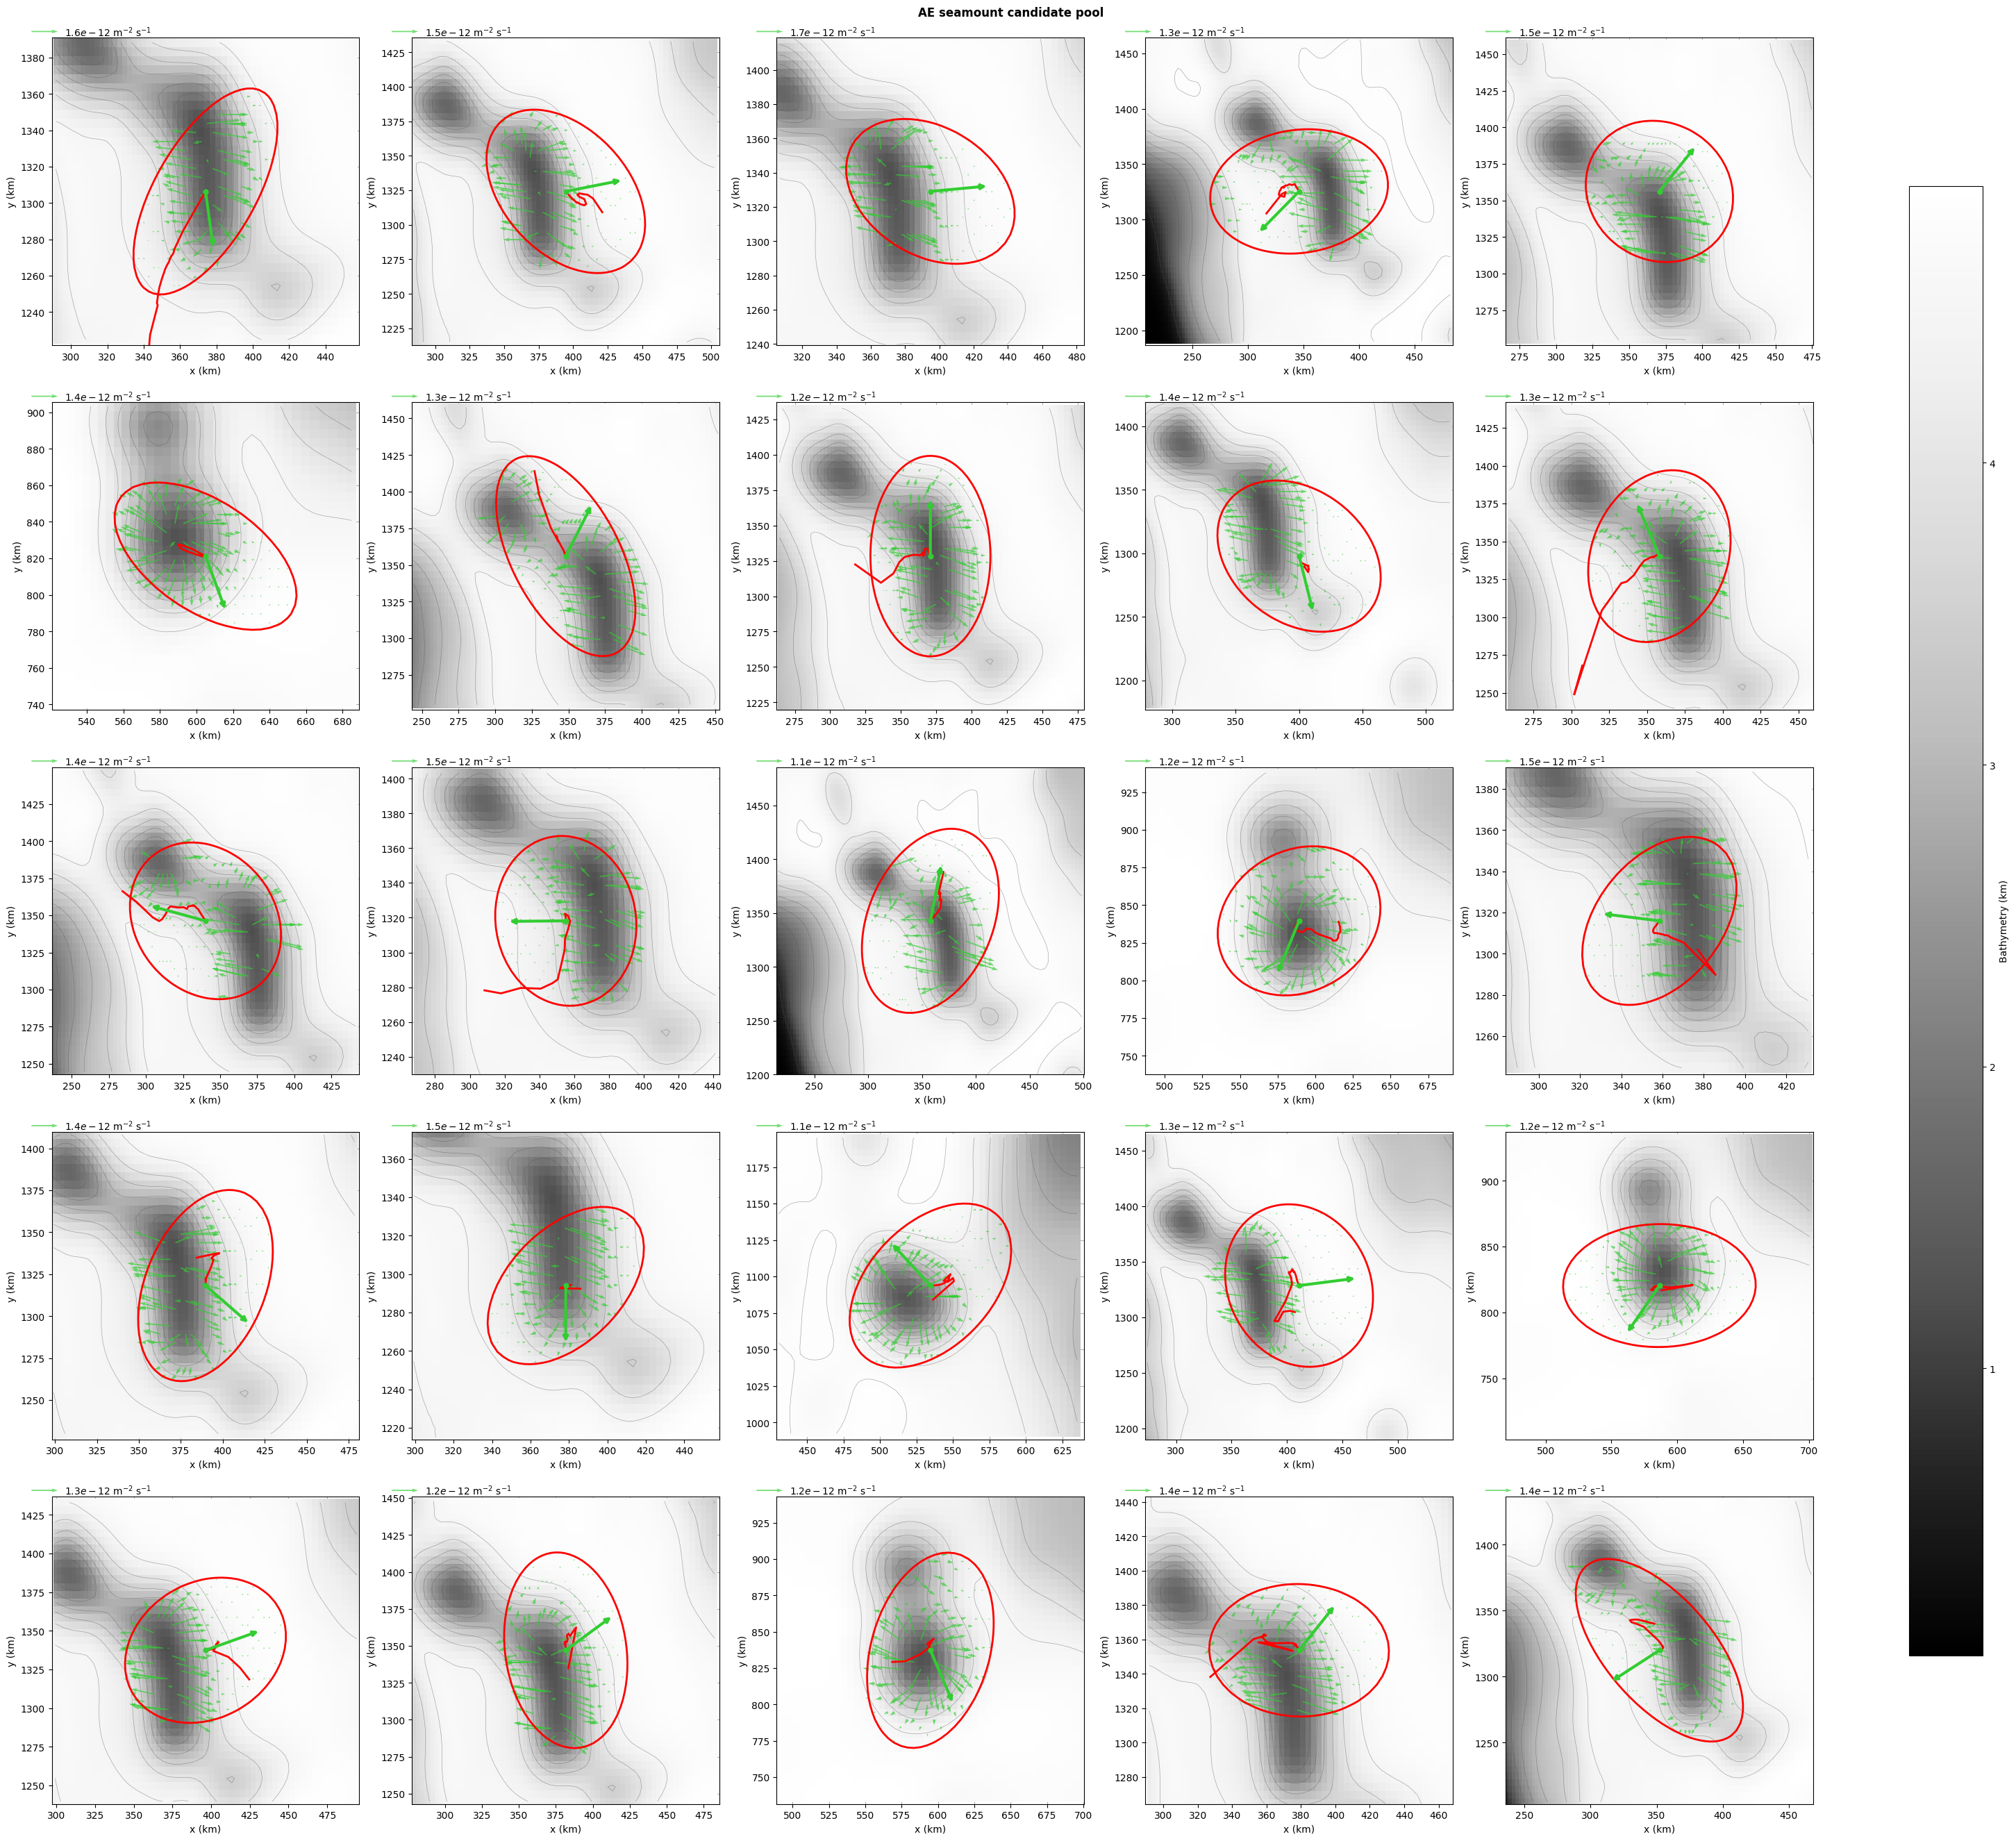

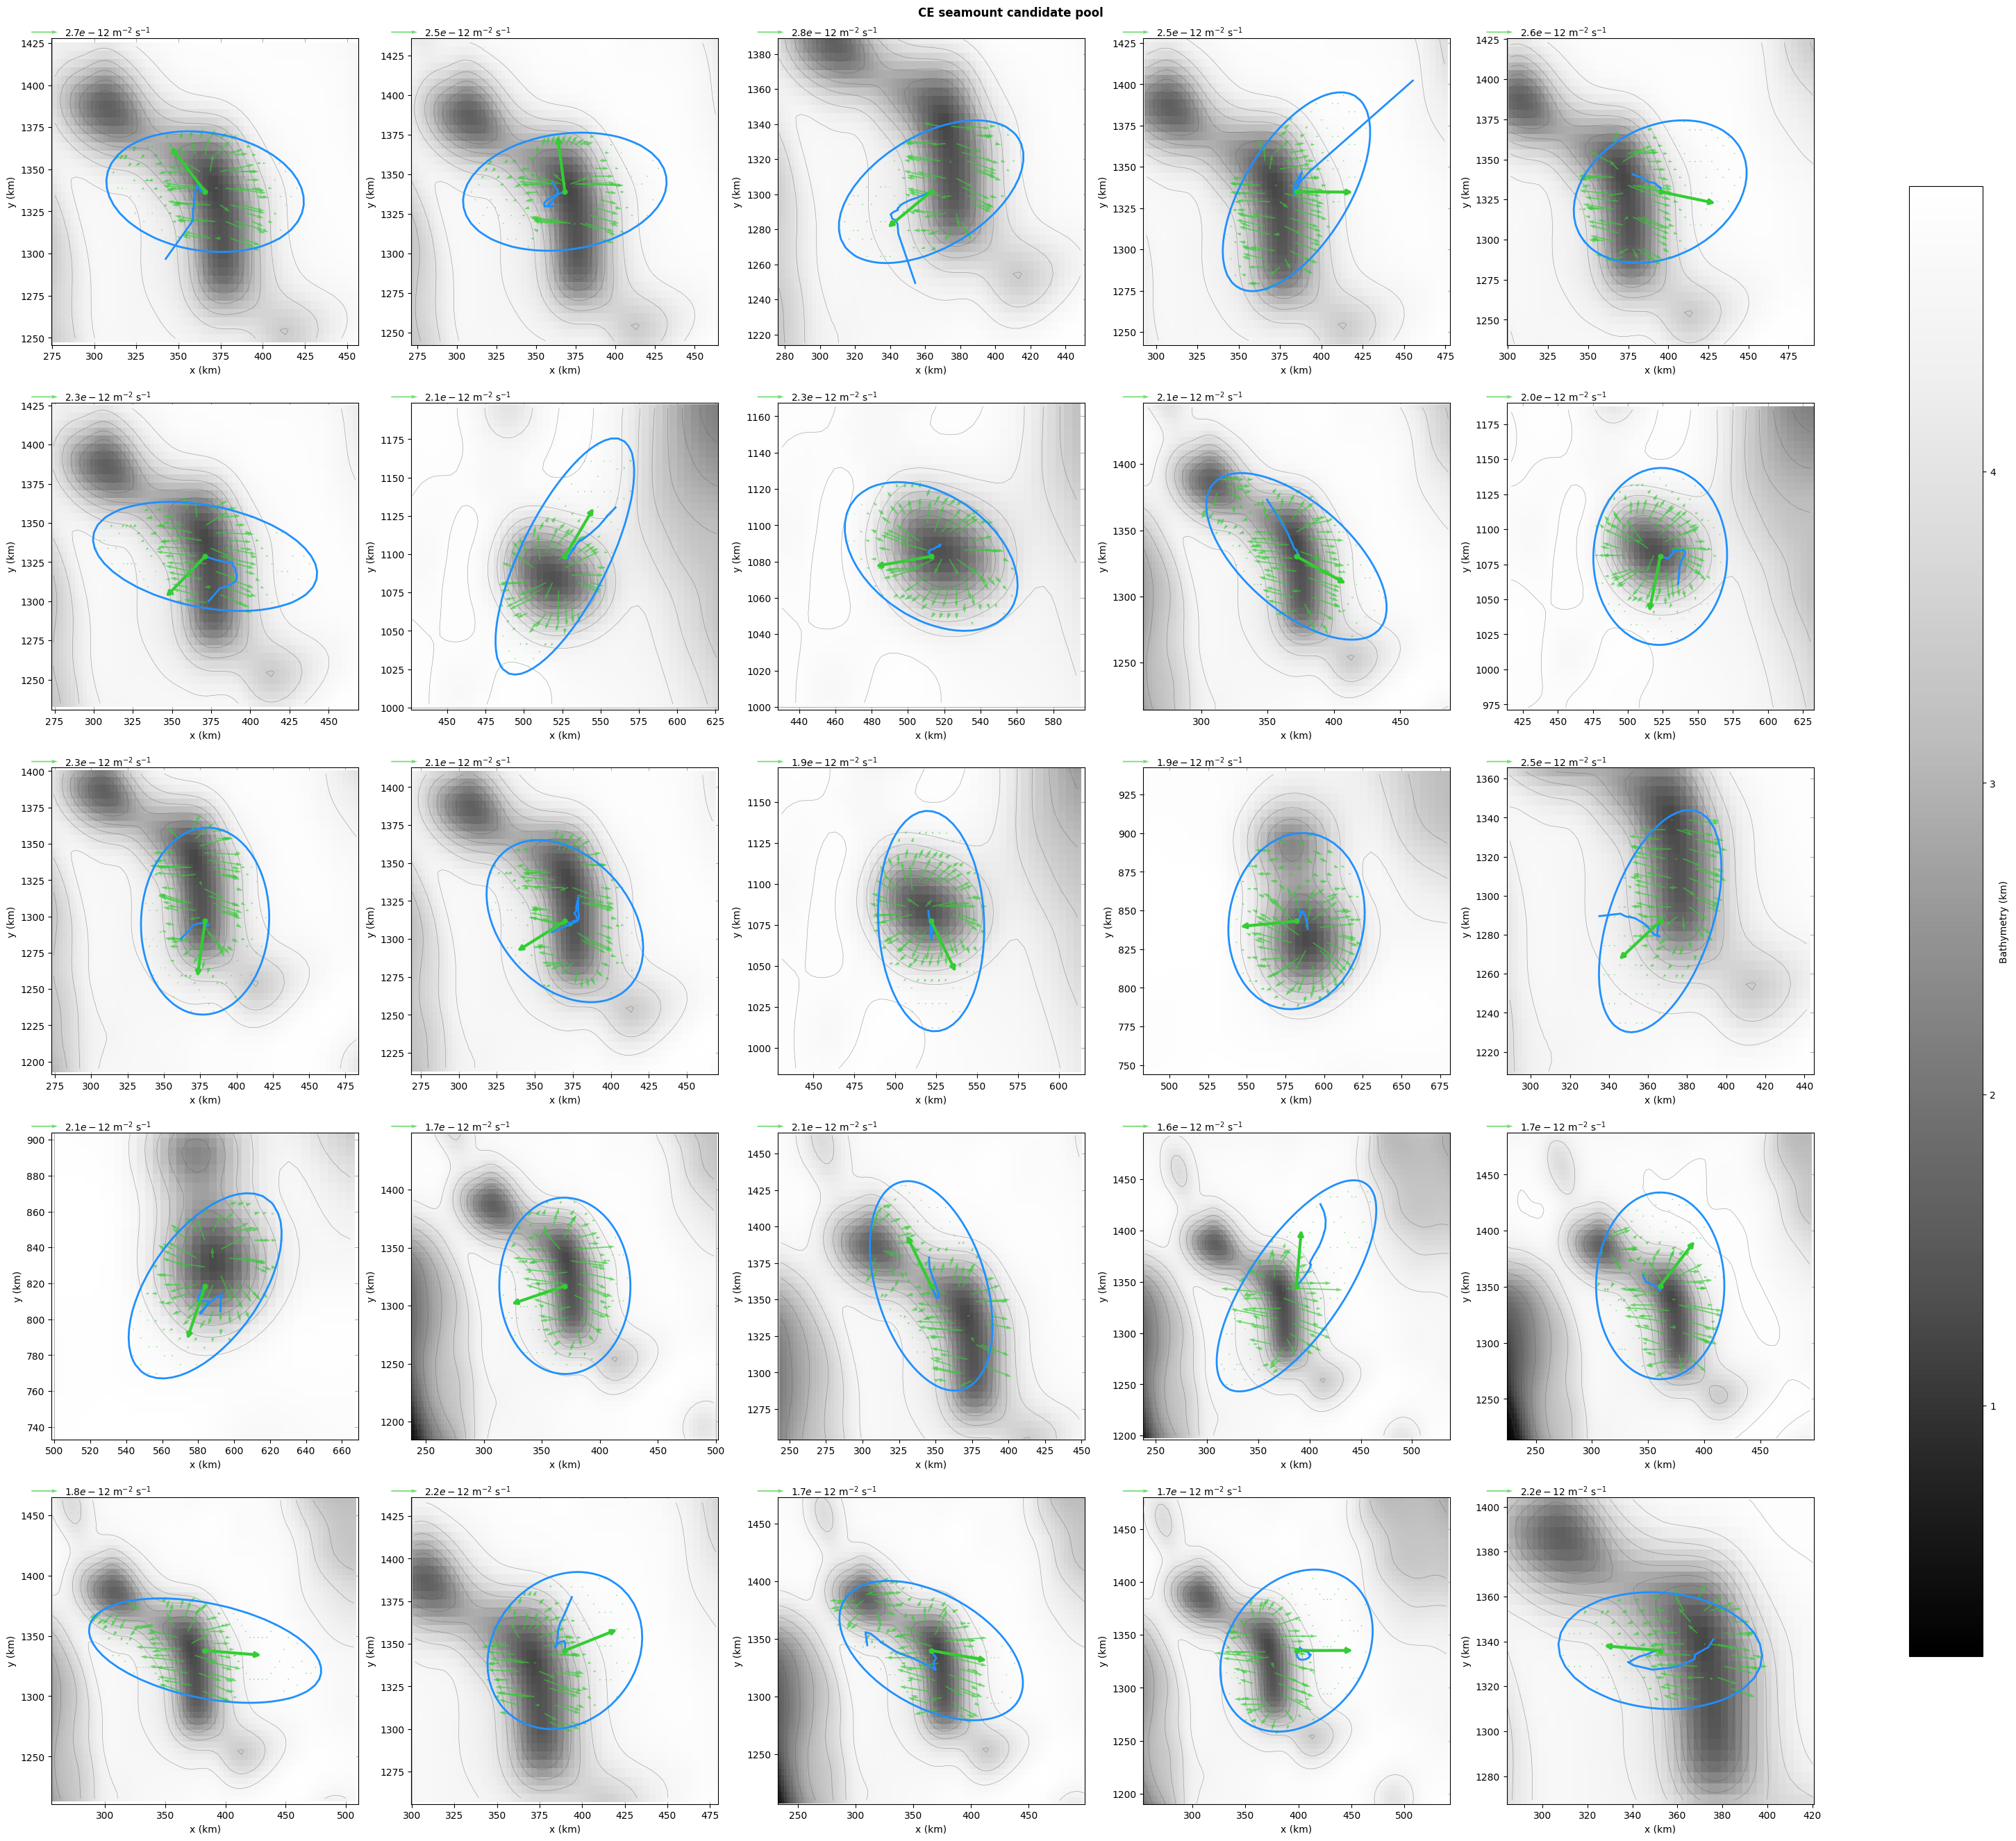

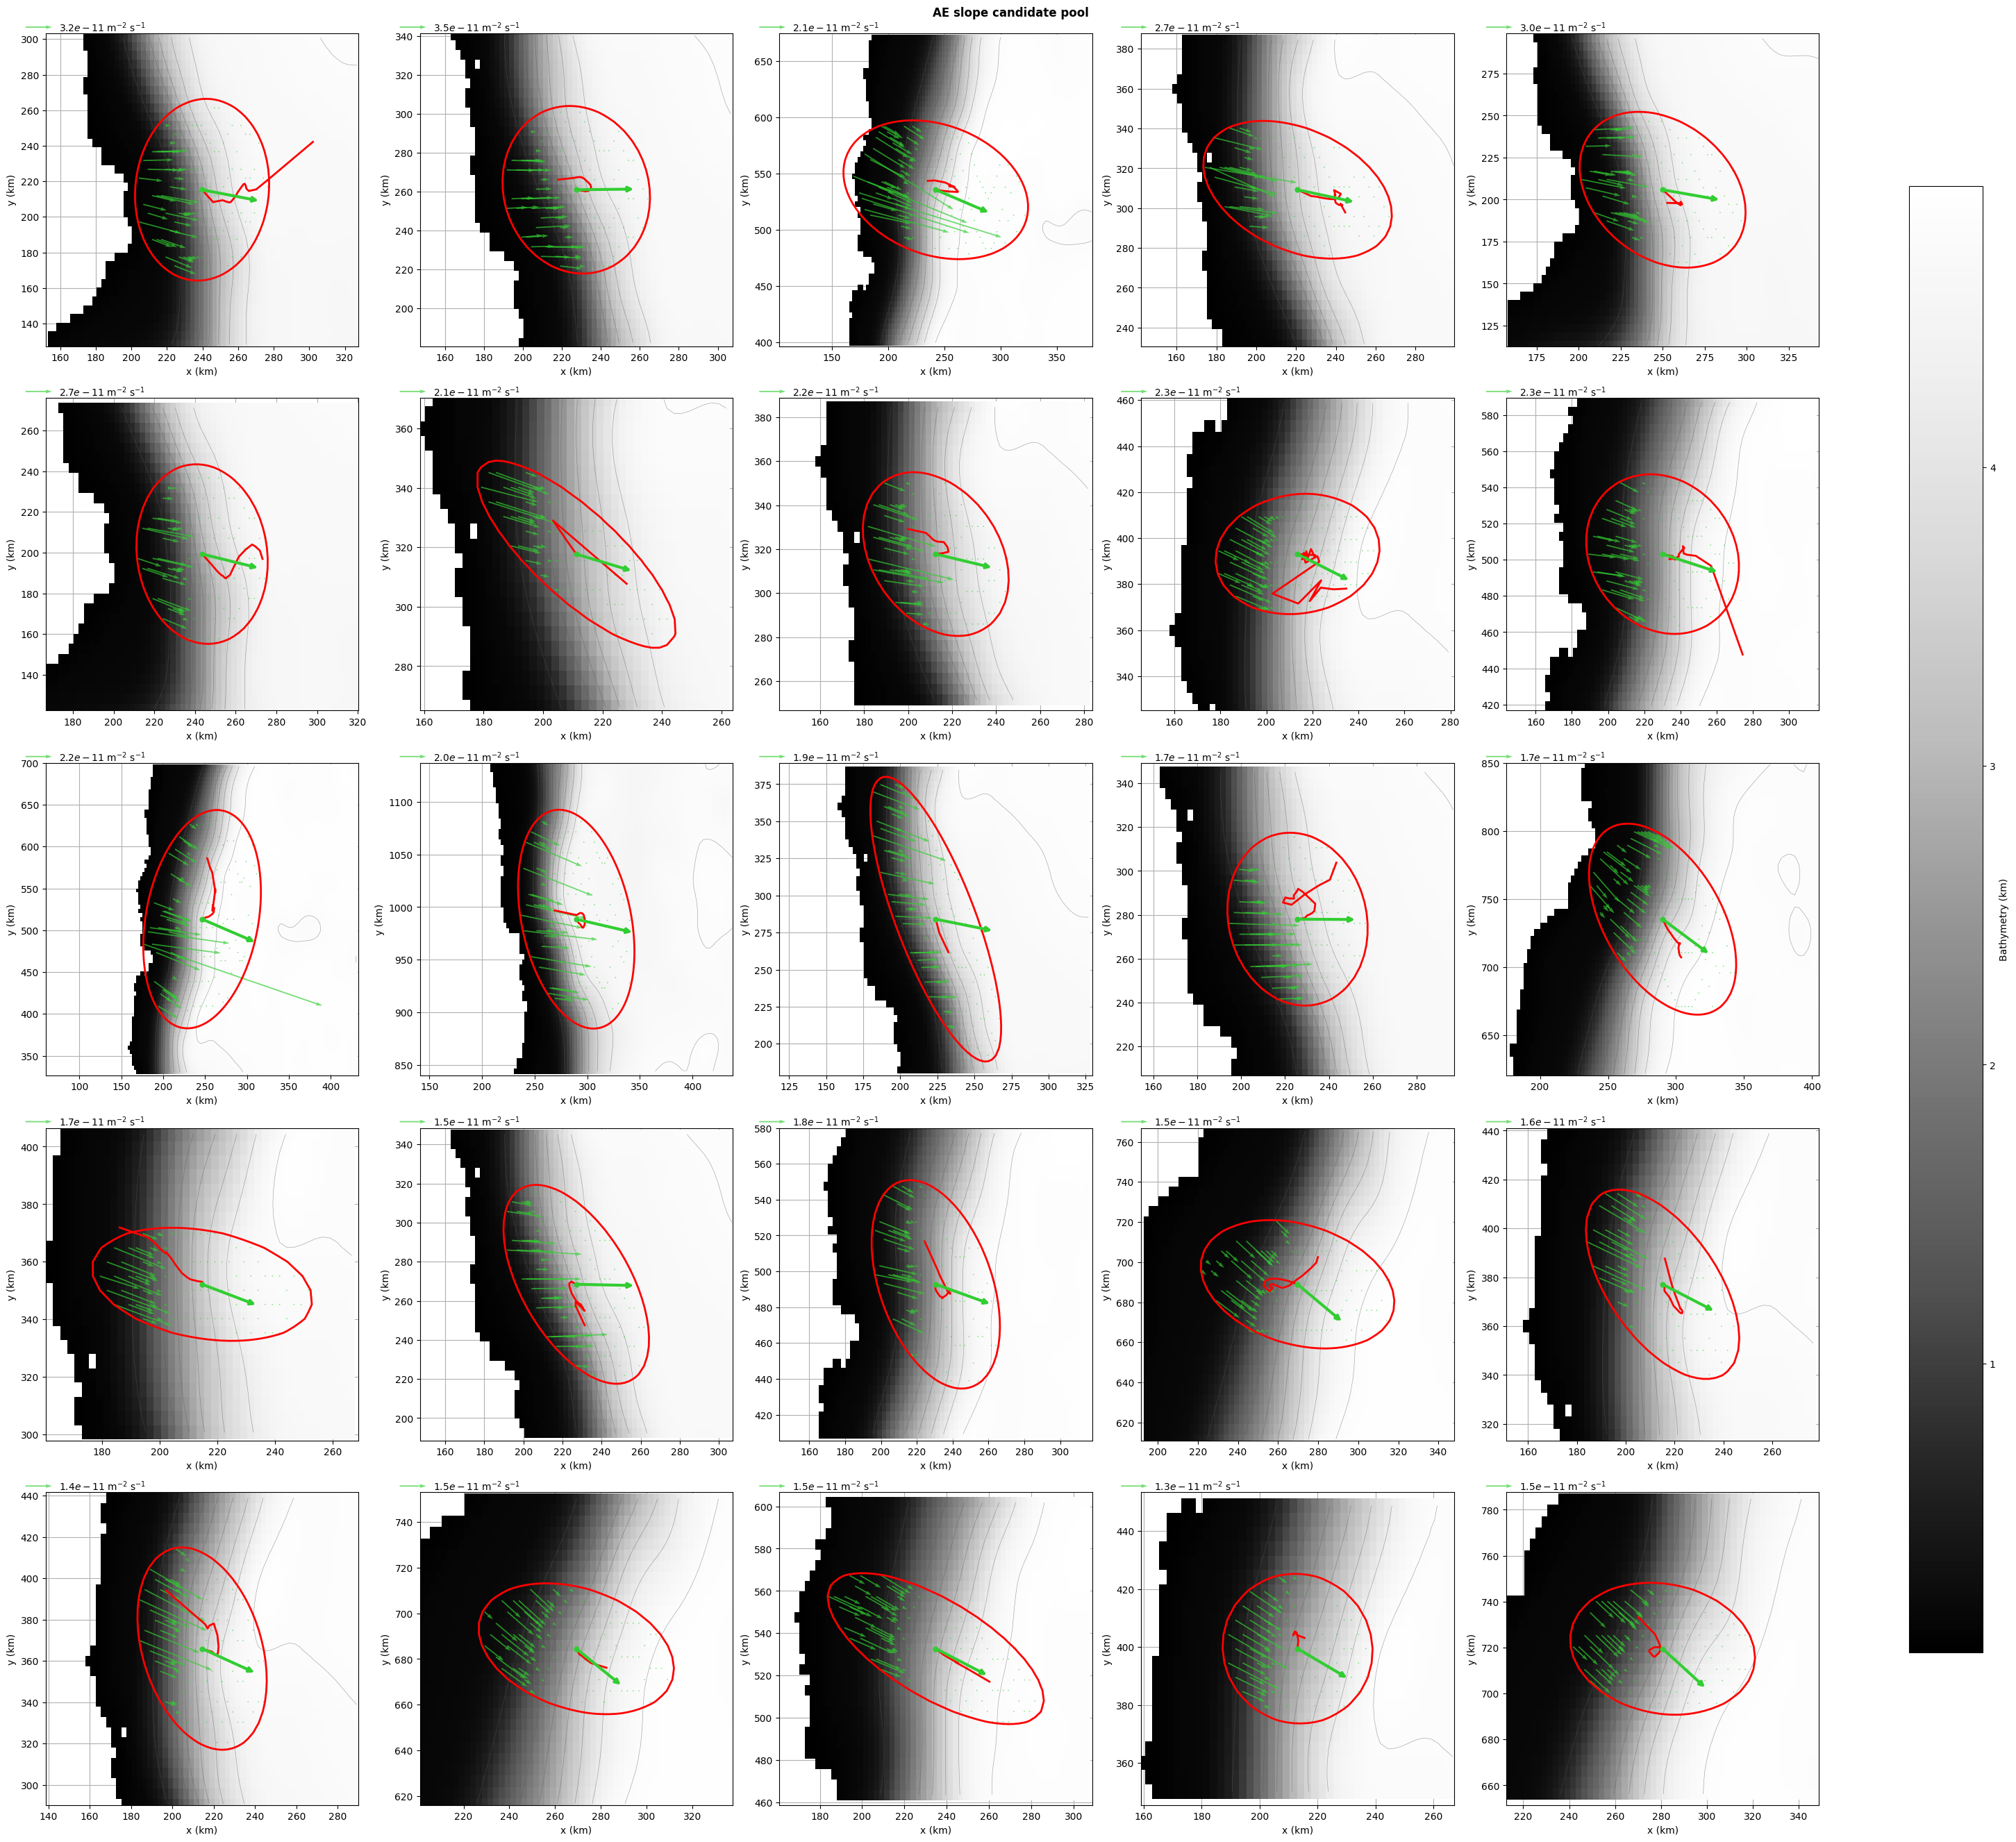

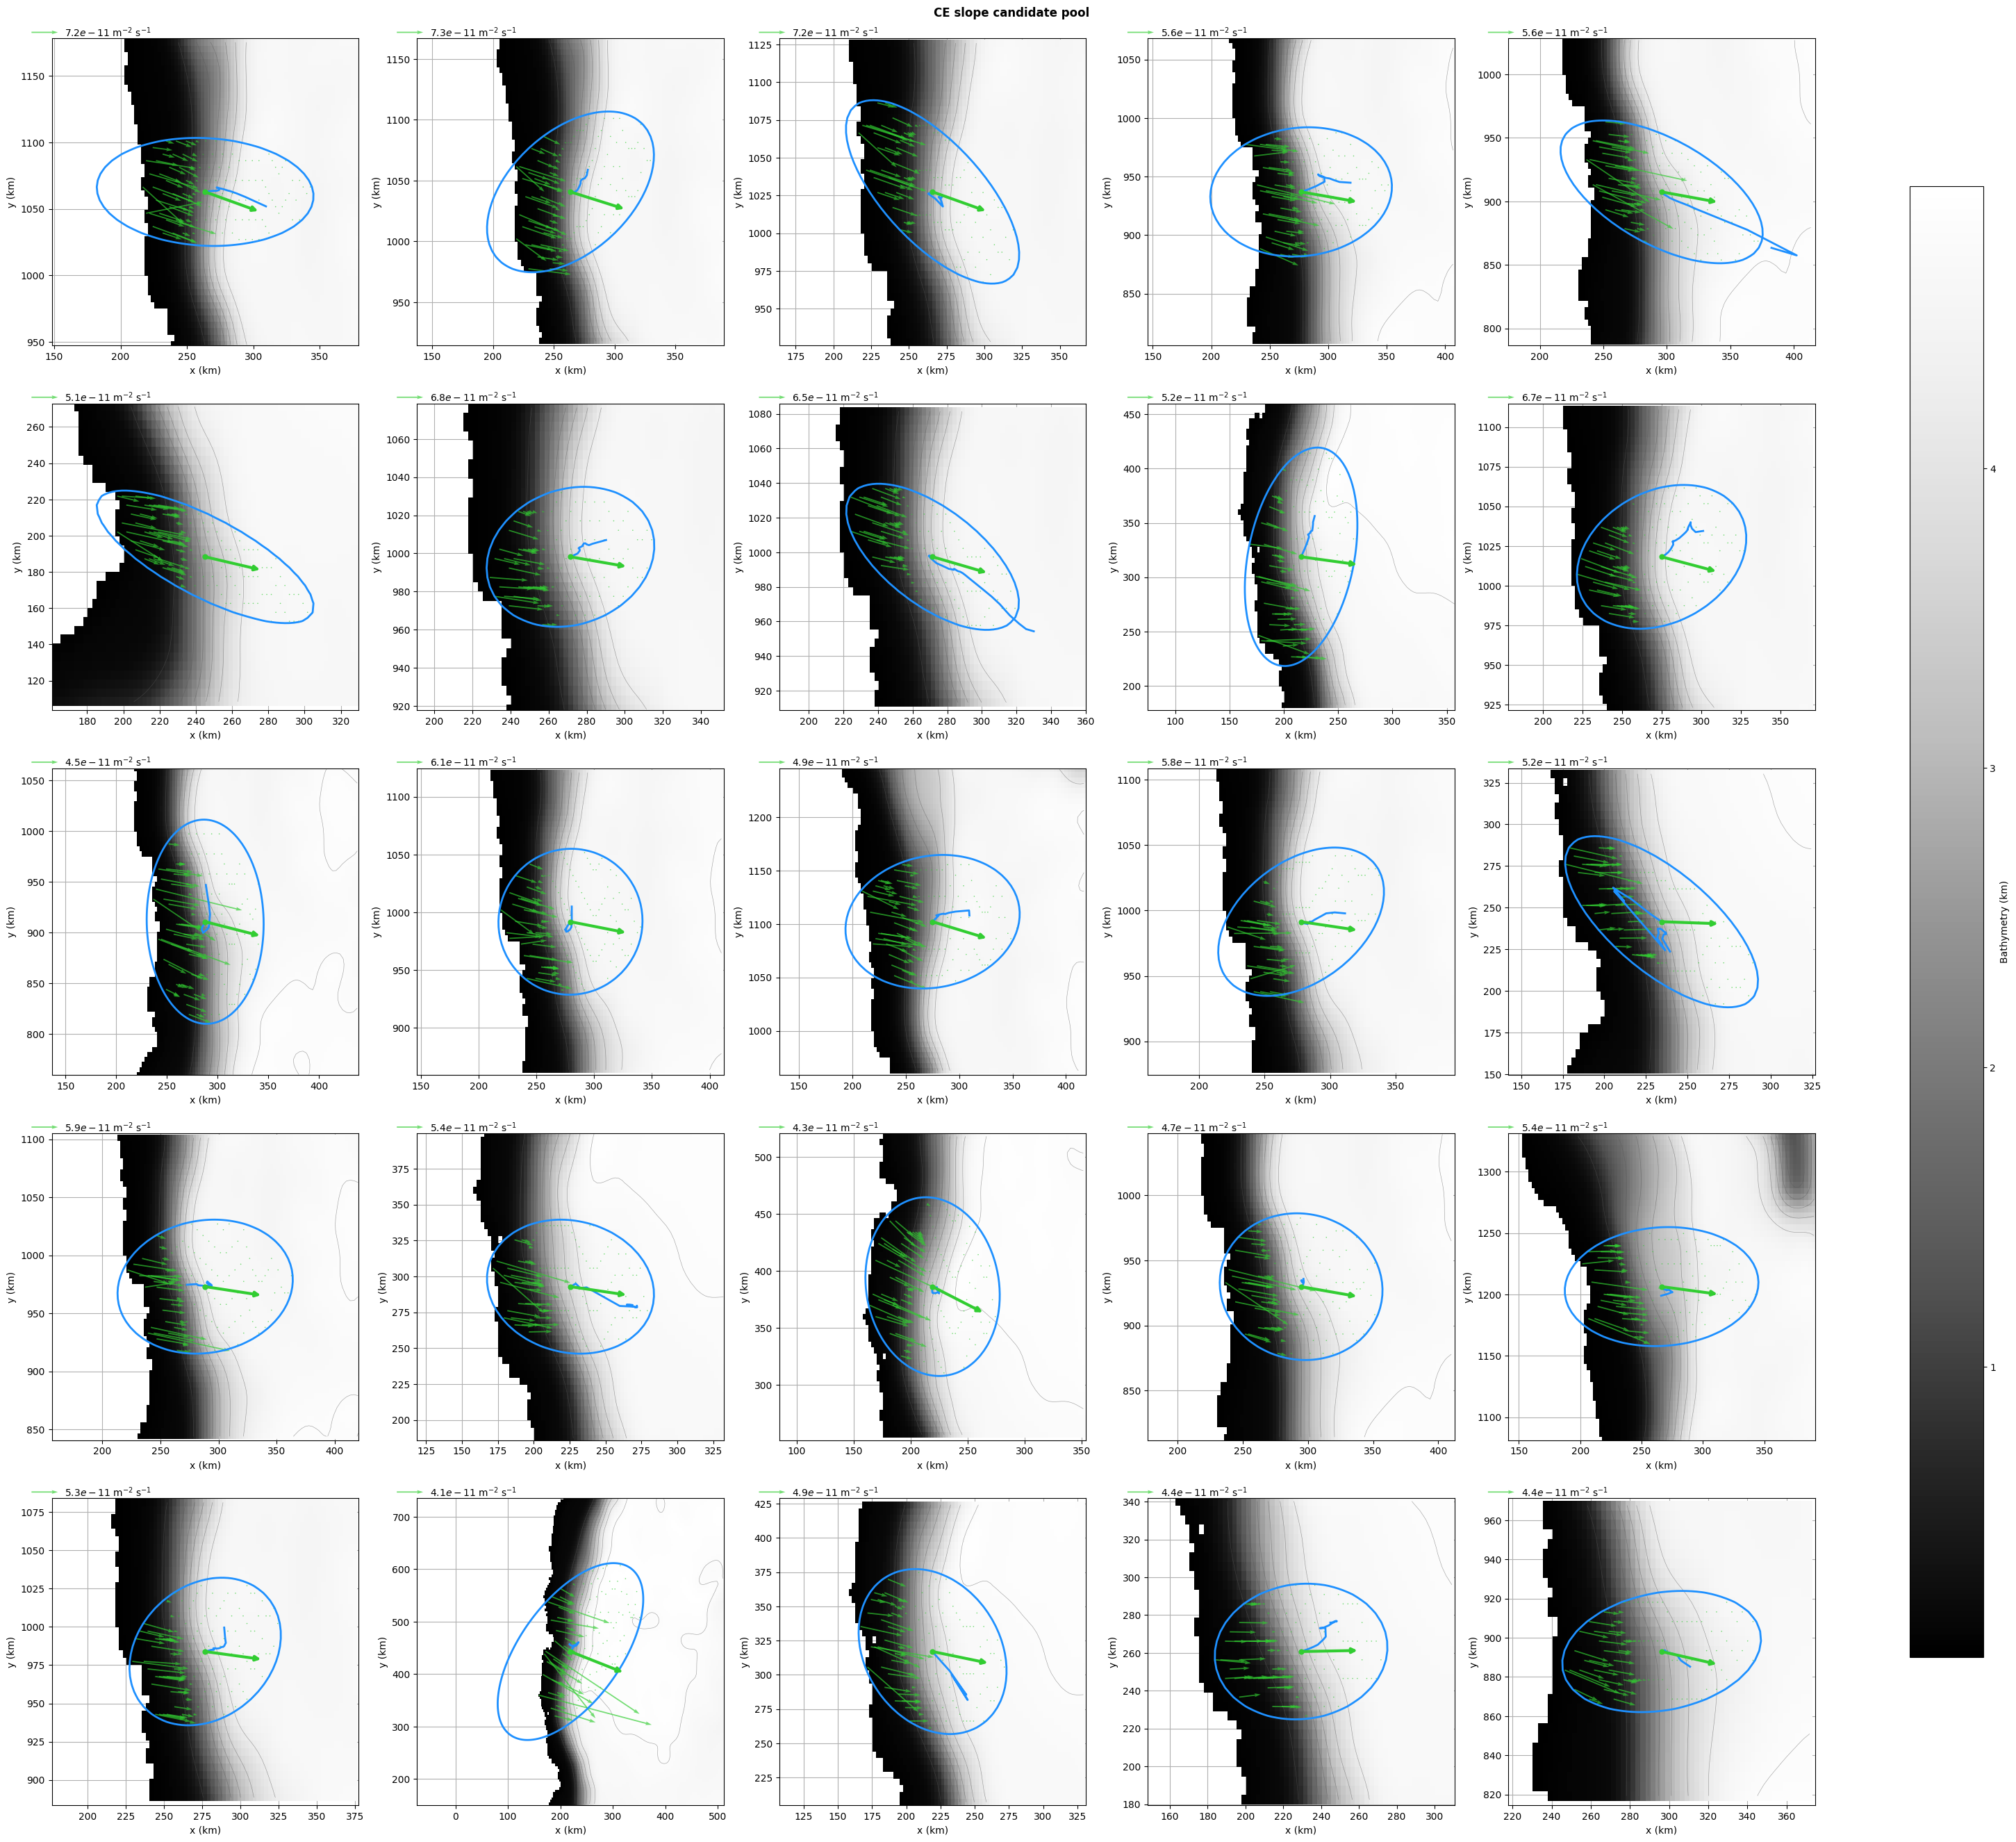

In [3]:
# Four simple galleries: 5 AE/CE seamount-like cases and 5 AE/CE slope cases.
for candidate_type in ('seamount', 'slope'):
    for cyc in ('AE', 'CE'):
        show = candidates[
            candidates.candidate_type.eq(candidate_type) & candidates.Cyc.eq(cyc)
        ].sort_values('rank')
        if show.empty:
            print(f'No {cyc} {candidate_type} candidates passed the current thresholds')
            continue
        fig, axes, local_references = ept.plot_gradient_examples(
            show, grid, vertical=vertical, legend=False, constrained_layout=True, #figsize=(20, 4.2)
        )
        fig.suptitle(f'{cyc} {candidate_type} candidate pool', fontweight='bold')
        plt.show()

## 2. Select two cases for the paper figure

Edit the candidate type, polarity and rank after inspecting the galleries. Red arrows are local environmental PV-gradient vectors and share one scale within each panel. The magenta arrow gives the direction of their Gaussian-weighted vector mean and has a fixed display length; its true magnitude is reported in the panel legend. The green line shows the fitted eddy centres with depth.

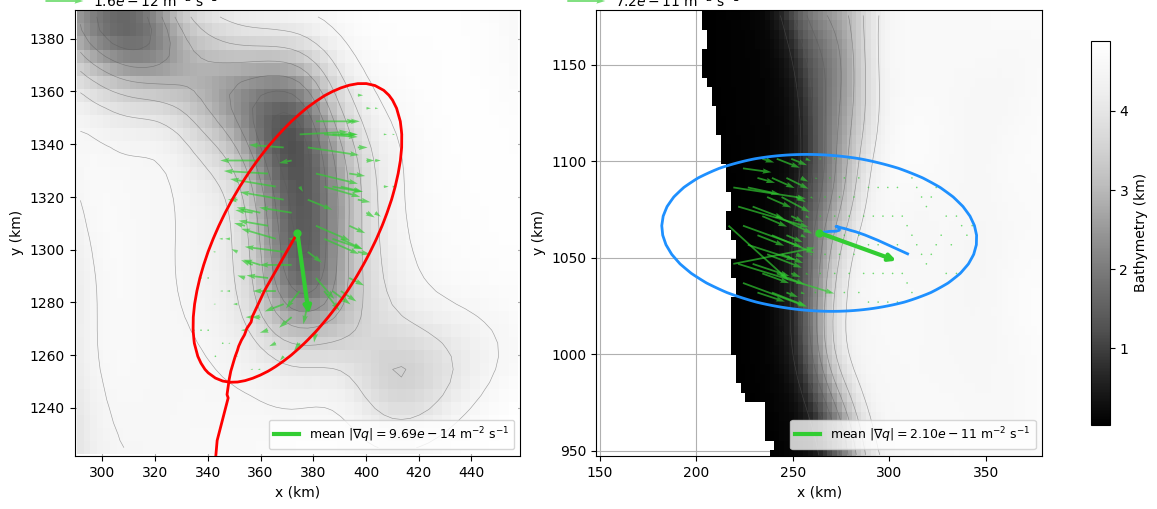

In [4]:
FINAL_SELECTION = [
    {'candidate_type': 'seamount', 'Cyc': 'AE', 'rank': 1},
    {'candidate_type': 'slope',    'Cyc': 'CE', 'rank': 1},
]

selected = pd.concat([
    candidates[
        candidates.candidate_type.eq(choice['candidate_type'])
        & candidates.Cyc.eq(choice['Cyc'])
        & candidates['rank'].eq(choice['rank'])
    ]
    for choice in FINAL_SELECTION
], ignore_index=True)
if len(selected) != 2:
    raise ValueError('Each FINAL_SELECTION entry must match one candidate row')

fig, axes, local_references = ept.plot_gradient_examples(
    selected, grid, vertical=vertical, figsize=(11.5, 5.1)
)
plt.show()

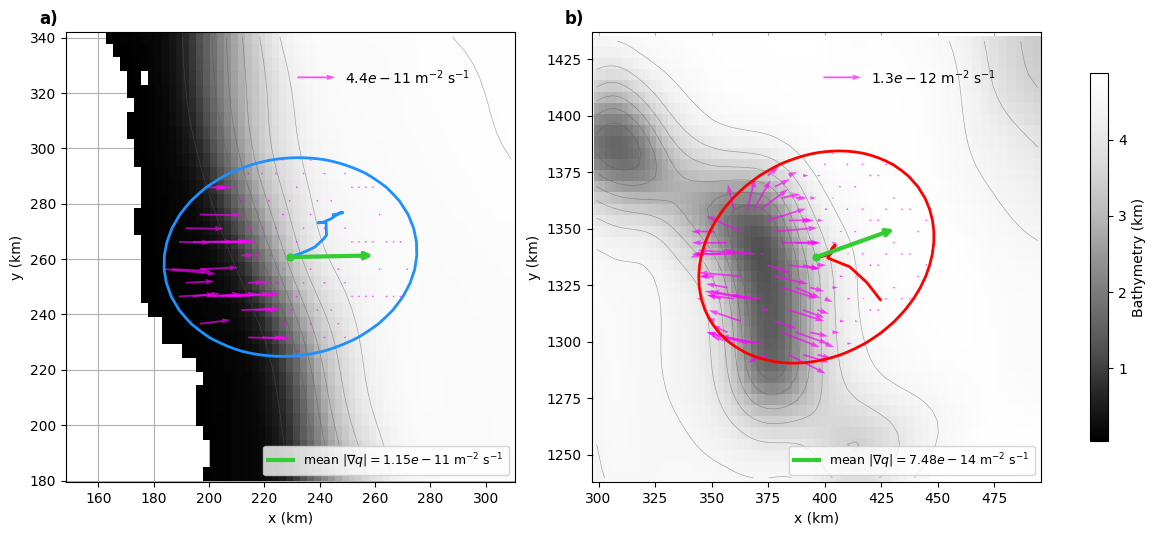

In [5]:
FINAL_SELECTION = [
    {'Eddy': 613, 'Day': 3370},
    {'Eddy': 76, 'Day': 1675},
]

selected = pd.concat([
    candidates[
        candidates['Eddy'].eq(choice['Eddy'])
        & candidates['Day'].eq(choice['Day'])
    ]
    for choice in FINAL_SELECTION
], ignore_index=True)

if len(selected) != len(FINAL_SELECTION):
    raise ValueError('Each FINAL_SELECTION entry must match exactly one eddy-day')

fig, axes, local_references = ept.plot_gradient_examples(
    selected,
    grid,
    vertical=vertical,
    figsize=(11.5, 5.1),
    xq=.6, 
    yq=.9,
    title=False,
    quiv_clr='magenta'
)

for ax,l in zip(axes,['a)','b)']):
    ax.text(-.06,1.05,l,transform=ax.transAxes,ha='left',va='top',
            fontsize=12,fontweight='bold')

plt.show()